In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [9]:
env = gym.make("Acrobot-v1", render_mode=None)

# Turn continuous state space into discrete state space
n_bin_edges = 15
costh1 = np.linspace(env.observation_space.low[0], env.observation_space.high[0], n_bin_edges)
sinth1 = np.linspace(env.observation_space.low[1], env.observation_space.high[1], n_bin_edges)
costh2 = np.linspace(env.observation_space.low[2], env.observation_space.high[2], n_bin_edges)
sinth2 = np.linspace(env.observation_space.low[3], env.observation_space.high[3], n_bin_edges)
omega1 = np.linspace(env.observation_space.low[4], env.observation_space.high[4], n_bin_edges)
omega2 = np.linspace(env.observation_space.low[5], env.observation_space.high[5], n_bin_edges)
state_space = np.vstack((costh1, sinth1, costh2, sinth2, omega1, omega2))

# q = np.zeros((len(costh1)-1, len(sinth1)-1, 
#               len(costh2)-1, len(sinth2)-1, 
#               len(omega1)-1, len(omega2)-1,
#               env.action_space.n))

with open('acrobot.pkl', 'rb') as f:
    q = pickle.load(f)

Episode: 100, Epsilon: 0.00, Best Reward: -109.0, Mean Rewards -204.2
Episode: 200, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -207.9
Episode: 300, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -202.5
Episode: 400, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -210.6
Episode: 500, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -222.0
Episode: 600, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -204.4
Episode: 700, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -232.9
Episode: 800, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -247.2
Episode: 900, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -256.2
Episode: 1000, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -245.0
Episode: 1100, Epsilon: 0.00, Best Reward: -107.0, Mean Rewards -212.9
Episode: 1200, Epsilon: 0.00, Best Reward: -88.0, Mean Rewards -235.4
Episode: 1300, Epsilon: 0.00, Best Reward: -88.0, Mean Rewards -238.6
Episode: 1400, Epsilon: 0.00, Best Reward: -88.0, Mean Rewards -253.2
Episode: 1500, Eps

KeyboardInterrupt: 

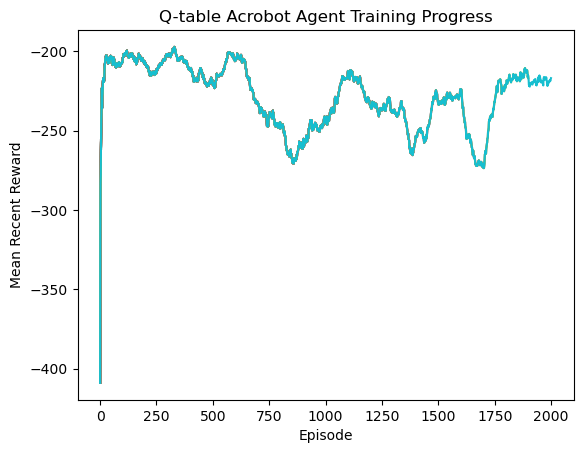

In [10]:
# Q-learning hyperparameters
alpha = 0.1                     # Learning rate
gamma = 0.95                    # Discount factor
epsilon = 0                     # Probability of random action
epsilon_min = 0.00              # Minimum probability of random action
epsilon_decay = 0.00005         # Epsilon decay after each episode

best_reward = float('-inf')     # Best reward from any episode
mean_reward = float('-inf')     # Mean reward over the last n (specified later) episodes
rewards_per_episode = []        # Rewards of each episode

epoch = 0                       # Index of current epoch of training

while (True):
    observation = env.reset(seed=0)[0]
    state = np.zeros(state_space.shape[0], dtype=int)
    
    # Encode discrete state from continuous observation. The -1's and min() prevent IndexErrors through finagling
    for i in range(len(observation)):
        state[i] = min(np.digitize(observation[i], state_space[i])-1, q.shape[0]-1)

    new_observation = np.zeros(len(observation))
    new_state = np.zeros(state_space.shape[0], dtype=int)

    rewards = 0               # Total reward over one episode
    terminated = False        # Whether the goal has been reached this episode
    
    while not terminated:    
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q[*state, :])

        new_observation, reward, terminated, _, _ = env.step(action)
        for i in range(len(observation)):
            new_state[i] = min(np.digitize(new_observation[i], state_space[i])-1, q.shape[0]-1)
            
        q[*state, action] += alpha * (reward + gamma * np.max(q[*new_state, :]) - q[*state, action])

        observation[:] = new_observation
        state[:] = new_state
        
        rewards += reward

    rewards_per_episode.append(rewards)
    
    if (rewards > best_reward):
        best_reward = rewards
        f = open('acrobot.pkl', 'wb')
        pickle.dump(q, f)
        f.close()
        
    if epoch != 0 and epoch % 100 == 0:
        mean_reward = np.mean(rewards_per_episode[len(rewards_per_episode)-100:])
        print(f"Episode: {epoch}, Epsilon: {epsilon:0.2f}, Best Reward: {best_reward:0.1f}, Mean Rewards {mean_reward:0.1f}")

        # Graph mean rewards
        mean_rewards = []
        for t in range(epoch):
            # Calculate mean reward over the t-100 episodes
            mean_rewards.append(np.mean(rewards_per_episode[max(0, t-100):(t+1)]))
        plt.plot(mean_rewards)
        plt.xlabel("Episode")
        plt.ylabel("Mean Recent Reward")
        plt.title("Q-table Acrobot Agent Training Progress")
        plt.savefig(f'acrobot.png')

    if mean_reward > env.spec.reward_threshold - 5:
        break
    
    epsilon = max(epsilon - epsilon_decay, epsilon_min)
    epoch += 1
    
env.close()

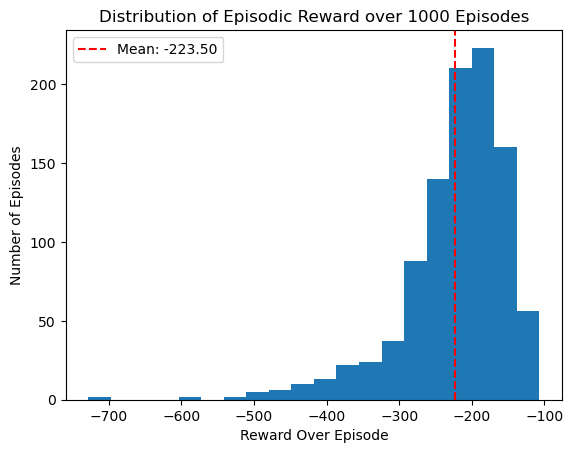

In [19]:
mean_reward = np.mean(rewards_per_episode[0:1000])
plt.hist(rewards_per_episode[0:1000], 20)
plt.xlabel("Reward Over Episode")
plt.ylabel("Number of Episodes")
plt.title("Distribution of Episodic Reward over 1000 Episodes")
plt.axvline(mean_reward, color='r', linestyle='dashed', label=f'Mean: {mean_reward:.2f}')
plt.legend()
plt.savefig('acrobot_test_q.png')